In [62]:
from generate_utils import load_GraphModel, load_BiLSTMModel, load_TokenBiLSTMModel, load_LoRASEModel, load_AdapterModel
import torch
import numpy as np
import pickle
from GridMLM_tokenizers import CSGridMLMTokenizer
import os
from eval_utils import get_vecser_for_file, vecser_similarity_matrix
from dotenv import load_dotenv
from tqdm import tqdm

# Load environment variables from .env file
load_dotenv()

True

In [63]:
tokenizer = CSGridMLMTokenizer(
    fixed_length=80,
    quantization='4th',
    intertwine_bar_info=True,
    trim_start=False,
    use_pc_roll=True,
    use_full_range_melody=False
)

In [64]:
def absoluteFilePaths(directory):
    file_names = []
    file_paths = []
    for dirpath,_,filenames in os.walk(directory):
        for f in filenames:
            if f.endswith( ('.mid', '.midi', '.mxl', '.xml', '.musicxml') ):
                file_names.append(f)
                file_paths.append(os.path.abspath(os.path.join(dirpath, f)))
    return file_names, file_paths

In [65]:
hook_file_names, hook_file_paths = absoluteFilePaths(os.getenv('VAL_HOOK'))
gjt_file_names, gjt_file_paths = absoluteFilePaths(os.getenv('VAL_GJT'))

In [66]:
print(hook_file_paths)

['/media/maindisk/data/mel_harm_CA_all/CA_test/13765_regina-spektor_all-the-rowboats_verse.mid', '/media/maindisk/data/mel_harm_CA_all/CA_test/15154_sia_elastic-heart_pre-chorus.mid', '/media/maindisk/data/mel_harm_CA_all/CA_test/17465_the-troggs_wild-thing_verse.mid', '/media/maindisk/data/mel_harm_CA_all/CA_test/10877_midlake_acts-of-man_intro-and-verse.mid', '/media/maindisk/data/mel_harm_CA_all/CA_test/11670_neru_the-disease-called-love_intro.mid', '/media/maindisk/data/mel_harm_CA_all/CA_test/9591_lindsey-stirling_elements_chorus.mid', '/media/maindisk/data/mel_harm_CA_all/CA_test/16510_the-bamboos_the-wilhelm-scream_outro.mid', '/media/maindisk/data/mel_harm_CA_all/CA_test/18078_tomoko-sasaki_song-of-courage_verse.mid', '/media/maindisk/data/mel_harm_CA_all/CA_test/10495_massive-attack_teardrop_verse.mid', '/media/maindisk/data/mel_harm_CA_all/CA_test/8052_judy-garland_over-the-rainbow_chorus.mid', '/media/maindisk/data/mel_harm_CA_all/CA_test/5818_gamma-ray_lake-of-tears_intro.m

In [67]:
device_name = 'cuda:0'
device = torch.device(device_name)

guide_arch = 'LoRA'
contra = True

adapter_model_path = f'saved_models/{guide_arch}/adapter/adapter_model_' + contra*'contra_' + 'jnhw.pt'
graph_adapter_model_path = f'saved_models/{guide_arch}/adapter/graph_model_' + contra*'contra_' + 'jnhw.pt'
token_adapter_model_path = f'saved_models/{guide_arch}/adapter/bilstm_model_' + contra*'contra_' + 'jnhw.pt'

token_adapter_model = load_TokenBiLSTMModel(token_adapter_model_path, tokenizer, device)
graph_adapter_model = load_GraphModel(graph_adapter_model_path, device)
adapter_model = load_AdapterModel(adapter_model_path, device)

token_adapter_model.eval()
graph_adapter_model.eval()
adapter_model.eval()

GuidanceAdapter(
  (proj): Linear(in_features=1024, out_features=512, bias=True)
)

In [68]:
test_vs = get_vecser_for_file(
    hook_file_paths[0],
    tokenizer,
    graph_model=graph_adapter_model,
    token_model=token_adapter_model,
    adapter_model=adapter_model
)

In [69]:
import numpy as np
x = (np.vstack(test_vs['adapter']))

In [70]:
print(x.shape)

(7, 512)


In [71]:
print(test_vs['chord_symbols'])

[['A:min'], ['F:maj', 'D:min'], ['A:min'], ['F:maj', 'D:min'], ['A:min'], ['F:maj', 'D:min'], ['A:min']]


In [72]:
# hook_VSs = []

# for p in tqdm(hook_file_paths):
#     hook_VSs.append(
#         get_vecser_for_file(
#             p,
#             tokenizer,
#             graph_model=graph_adapter_model,
#             token_model=token_adapter_model,
#             adapter_model=adapter_model
#         )
#     )

In [73]:
gjt_VSs = []

for p in tqdm(gjt_file_paths):
    gjt_VSs.append(
        get_vecser_for_file(
            p,
            tokenizer,
            graph_model=graph_adapter_model,
            token_model=token_adapter_model,
            adapter_model=adapter_model,
            seg_len=2,
            seg_step=1
        )
    )

100%|██████████| 28/28 [00:02<00:00, 11.90it/s]


In [74]:
import torch
cos = torch.nn.CosineSimilarity()

In [75]:
def vecser_similarity_matrix(v1, v2):
    m = np.zeros( (len(v1) , len(v2)) )
    for i in range(len(v1)):
        for j in range(len(v2)):
            m[i,j] = cos( torch.tensor(v1[i]), torch.tensor(v2[j]) )
    return m
# end vecser_similarity_matrix

In [76]:
gjt_VSs[3]['token'][0].shape

(1, 512)

In [77]:
p1, p2 = gjt_VSs[0], gjt_VSs[1]

In [78]:
m_adapter = vecser_similarity_matrix(p1['adapter'], p2['adapter'])
m_graph = vecser_similarity_matrix(p1['graph'], p2['graph'])
m_token = vecser_similarity_matrix(p1['token'], p2['token'])

In [79]:
print(m_graph.shape)

(15, 15)


In [80]:
import matplotlib.pyplot as plt

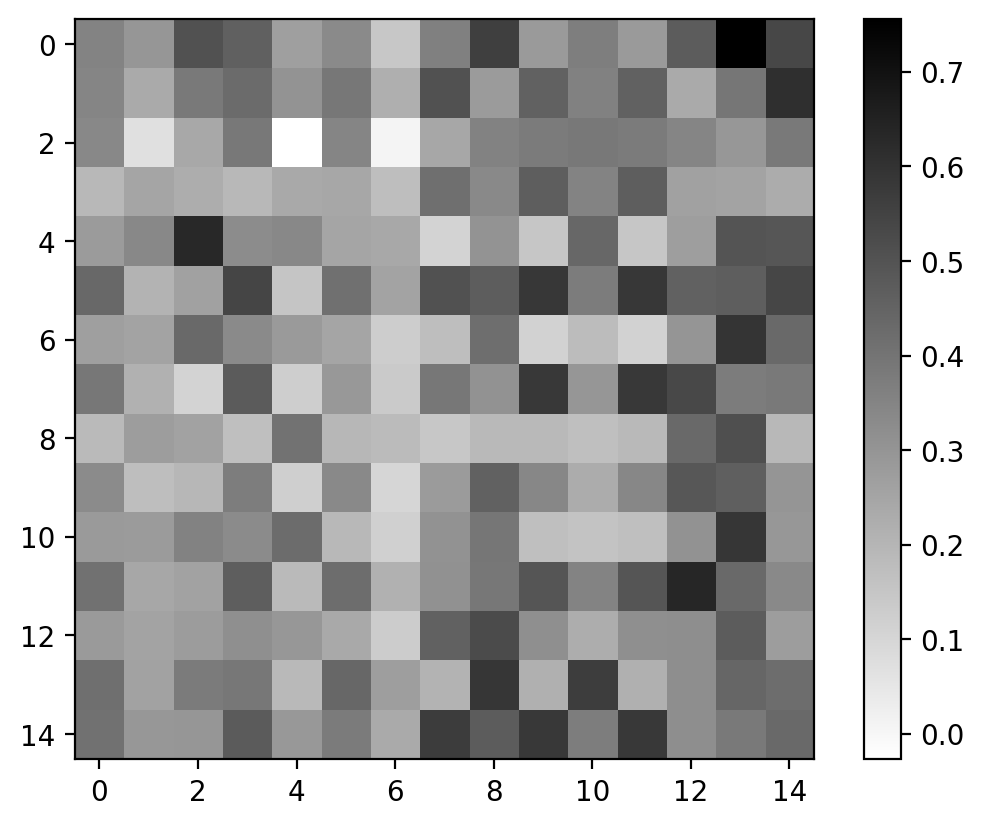

In [81]:
plt.imshow(m_adapter, cmap='gray_r')
plt.colorbar()

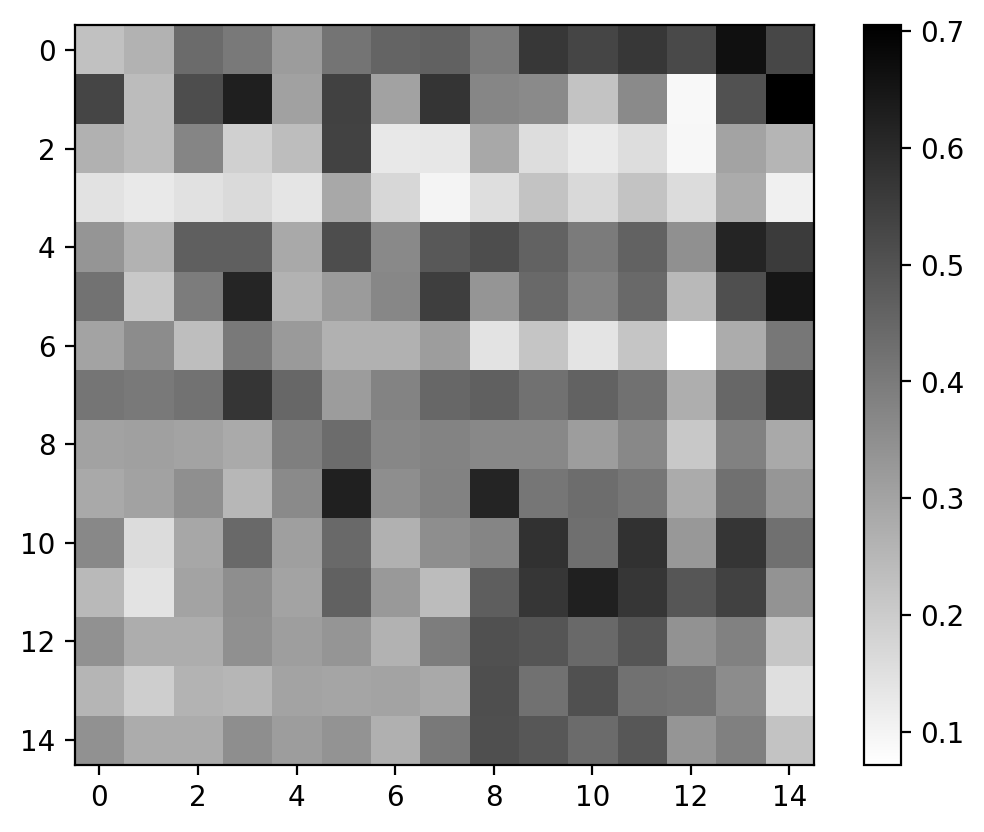

In [82]:
plt.imshow(m_graph, cmap='gray_r')
plt.colorbar()

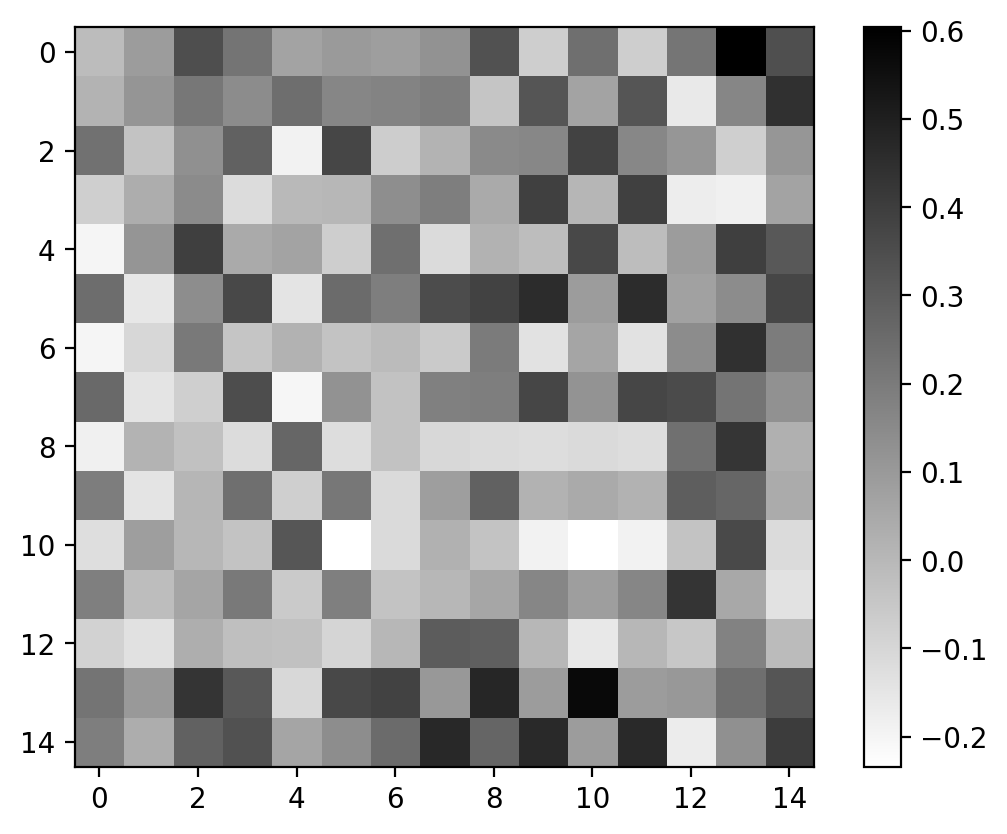

In [83]:
plt.imshow(m_token, cmap='gray_r')
plt.colorbar()

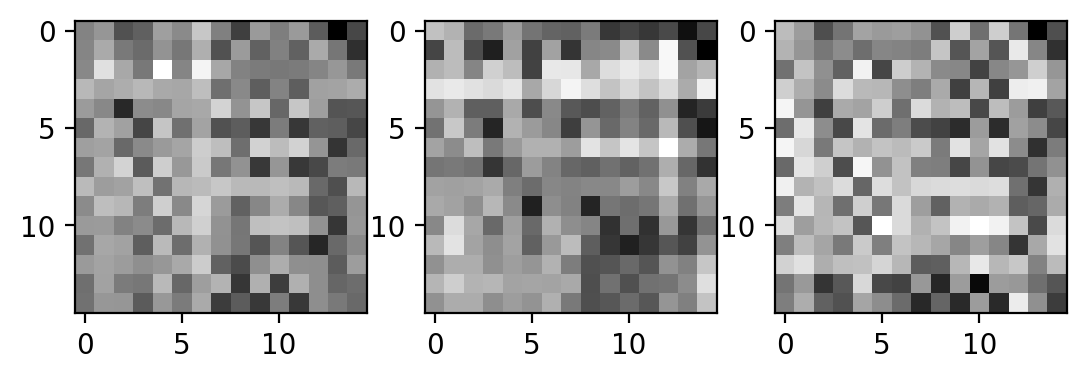

In [84]:
plt.subplot(1,3,1)
plt.imshow(m_adapter, cmap='gray_r')
plt.subplot(1,3,2)
plt.imshow(m_graph, cmap='gray_r')
plt.subplot(1,3,3)
plt.imshow(m_token, cmap='gray_r')

In [85]:
arr = -m_adapter
s = np.dstack(np.unravel_index(np.argsort(arr.ravel()), arr.shape))
print(s)

[[[ 0 13]
  [11 12]
  [ 4  2]
  [ 1 14]
  [ 6 13]
  [10 13]
  [13  8]
  [ 5 11]
  [ 5  9]
  [14 11]
  [14  9]
  [ 7 11]
  [ 7  9]
  [14  7]
  [13 10]
  [ 0  8]
  [ 5  3]
  [ 5 14]
  [ 0 14]
  [ 7 12]
  [12  8]
  [ 8 13]
  [ 0  2]
  [ 5  7]
  [ 1  7]
  [ 4 13]
  [11 11]
  [11  9]
  [ 4 14]
  [ 9 12]
  [14  3]
  [ 7  3]
  [14  8]
  [12 13]
  [ 0 12]
  [ 5  8]
  [ 3  9]
  [ 3 11]
  [ 5 13]
  [11  3]
  [ 9 13]
  [ 0  3]
  [ 5 12]
  [ 1  9]
  [ 1 11]
  [12  7]
  [ 9  8]
  [13 13]
  [13  5]
  [ 4 10]
  [ 5  0]
  [ 8 12]
  [ 6 14]
  [11 13]
  [14 14]
  [ 6  2]
  [ 1  3]
  [10  4]
  [11  5]
  [13 14]
  [ 6  8]
  [ 3  7]
  [13  0]
  [ 5  5]
  [11  0]
  [14  0]
  [ 8  4]
  [ 1 13]
  [10  8]
  [ 7  7]
  [ 1  5]
  [13  3]
  [11  8]
  [ 7  0]
  [ 2  3]
  [ 2 10]
  [14 13]
  [ 7 14]
  [ 2 14]
  [ 1  2]
  [ 2 11]
  [ 2  9]
  [14  5]
  [13  2]
  [ 7 13]
  [ 5 10]
  [14 10]
  [ 9  3]
  [ 0 10]
  [ 0  7]
  [ 1 10]
  [ 2  8]
  [10  2]
  [11 10]
  [ 3 10]
  [ 0  0]
  [ 2  5]
  [ 2 12]
  [ 1  0]
  [ 9 11]


In [86]:
for i in range(10):
    print(
        p1['chord_symbols'][s[0][i][0]],
        '-',
        p2['chord_symbols'][s[0][i][1]],
        ' | ', m_adapter[s[0][i][0], s[0][i][1]]
    )

['G:maj6', 'G#:dim7', 'A:min7', 'D:7'] - ['A:min', 'A:minmaj7', 'A:min7', 'D:7']  |  0.7554684281349182
['D:9', 'G:7', 'C:maj6'] - ['B:hdim7', 'E:7(b9)', 'A:min', 'A:minmaj7']  |  0.6378418803215027
['G:maj7', 'E:7', 'A:min7', 'D:7'] - ['D:min7', 'A#:maj7', 'A:min7', 'D:7']  |  0.6273502111434937
['A:min7', 'D:7', 'G:maj7', 'D:min7', 'G:7'] - ['A:min7', 'D:7', 'G:min7', 'D:7']  |  0.6111509203910828
['G:maj6', 'E:min7', 'A:7', 'D:7'] - ['A:min', 'A:minmaj7', 'A:min7', 'D:7']  |  0.5952460169792175
['C:maj6', 'D:9', 'G:7'] - ['A:min', 'A:minmaj7', 'A:min7', 'D:7']  |  0.5901589393615723
['F:7', 'E:7', 'A:min7'] - ['F:maj6', 'B:hdim7', 'E:7', 'A:min7']  |  0.5898996591567993
['A:min7', 'D:7', 'G:maj6', 'E:min7'] - ['A:min7', 'B:hdim7', 'E:7(b9)']  |  0.5861536264419556
['A:min7', 'D:7', 'G:maj6', 'E:min7'] - ['A:min7', 'B:hdim7', 'E:7(b9)']  |  0.5861536264419556
['A:min7', 'F:7', 'E:7'] - ['A:min7', 'B:hdim7', 'E:7(b9)']  |  0.5826746225357056


In [87]:
p_idx = 4

original_gjt_path = gjt_file_paths[p_idx]
original_gjt_name = gjt_file_names[p_idx]
original_gjt_name_no_ext = original_gjt_name.split('.')[0]
print(original_gjt_path)
print(original_gjt_name)
print(original_gjt_name_no_ext)

gen_gjt_file_names, gen_gjt_file_paths = absoluteFilePaths('MIDIs/no_guide')

gen_gjt_path = None
real_gjt_path = None
for i, g in enumerate(gen_gjt_file_names):
    if 'gen_' in g:
        if g.split('gen_')[1].split('.')[0] == original_gjt_name_no_ext:
            gen_gjt_path = gen_gjt_file_paths[i]
    if 'real_' in g:
        if g.split('real_')[1].split('.')[0] == original_gjt_name_no_ext:
            real_gjt_path = gen_gjt_file_paths[i]

print(gen_gjt_path)
print(real_gjt_path)

/media/maindisk/data/mel_harm_CA_all/gjt_CA_test/There_Is_No_Greater_Love.mxl
There_Is_No_Greater_Love.mxl
There_Is_No_Greater_Love
/media/maindisk/maximos/repos/GraphMelHarm/MIDIs/no_guide/gen_There_Is_No_Greater_Love.mxl_no.mid
/media/maindisk/maximos/repos/GraphMelHarm/MIDIs/no_guide/real_There_Is_No_Greater_Love.mxl_no.mid


In [88]:
original_vs = get_vecser_for_file(
    original_gjt_path,
    tokenizer,
    graph_model=graph_adapter_model,
    token_model=token_adapter_model,
    adapter_model=adapter_model
)

gen_vs = get_vecser_for_file(
    gen_gjt_path,
    tokenizer,
    graph_model=graph_adapter_model,
    token_model=token_adapter_model,
    adapter_model=adapter_model
)

real_vs = get_vecser_for_file(
    real_gjt_path,
    tokenizer,
    graph_model=graph_adapter_model,
    token_model=token_adapter_model,
    adapter_model=adapter_model
)

In [89]:
m_adapter = vecser_similarity_matrix(original_vs['adapter'], gen_vs['adapter'])
m_graph = vecser_similarity_matrix(original_vs['graph'], gen_vs['graph'])
m_token = vecser_similarity_matrix(original_vs['token'], gen_vs['token'])

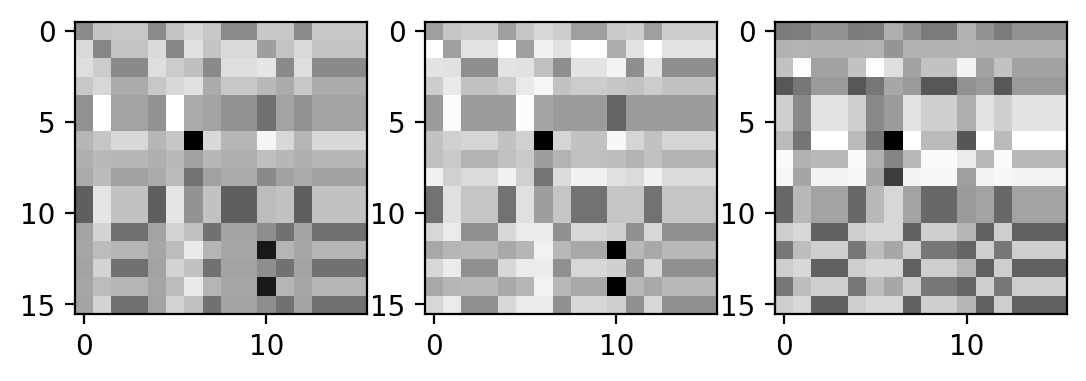

In [90]:
plt.subplot(1,3,1)
plt.imshow(m_adapter, cmap='gray_r')
plt.subplot(1,3,2)
plt.imshow(m_graph, cmap='gray_r')
plt.subplot(1,3,3)
plt.imshow(m_token, cmap='gray_r')

In [91]:
arr = -m_adapter
# arr = -m_token
# arr = -m_graph
s = np.dstack(np.unravel_index(np.argsort(arr.ravel()), arr.shape))

for i in range(10):
    print(
        original_vs['chord_symbols'][s[0][i][0]],
        '-',
        gen_vs['chord_symbols'][s[0][i][1]],
        ' | ', m_adapter[s[0][i][0], s[0][i][1]]
    )

['D:min7'] - ['D:min7']  |  0.9999997615814209
['A:min6'] - ['F#:hdim7']  |  0.9000718593597412
['A:min6'] - ['F#:hdim7']  |  0.9000718593597412
['C:maj6'] - ['A:min']  |  0.6257915496826172
['C:maj6'] - ['A:min']  |  0.6257915496826172
['C:maj6'] - ['A:min']  |  0.6257915496826172
['C:maj6'] - ['A:min']  |  0.6257915496826172
['C:maj6'] - ['A:min']  |  0.6257915496826172
['C:maj6'] - ['A:min']  |  0.6257915496826172
['C:maj6'] - ['A:min']  |  0.6257915496826172


In [92]:
print(np.corrcoef(m_adapter.ravel(), m_graph.ravel())[0,1])
print(np.corrcoef(m_adapter.ravel(), m_token.ravel())[0,1])
print(np.corrcoef(m_graph.ravel(), m_token.ravel())[0,1])

0.8694224469843392
0.4195808085147876
0.4556547409819774


In [93]:
m_adapter = vecser_similarity_matrix(original_vs['adapter'], real_vs['adapter'])
m_graph = vecser_similarity_matrix(original_vs['graph'], real_vs['graph'])
m_token = vecser_similarity_matrix(original_vs['token'], real_vs['token'])

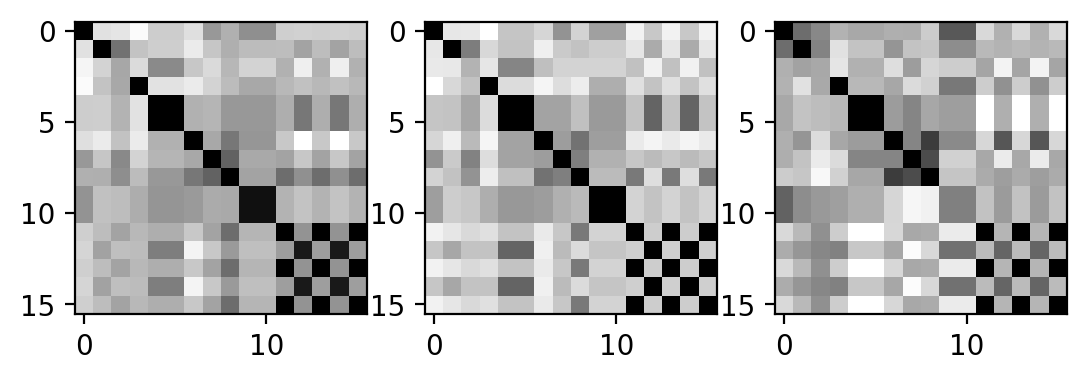

In [94]:
plt.subplot(1,3,1)
plt.imshow(m_adapter, cmap='gray_r')
plt.subplot(1,3,2)
plt.imshow(m_graph, cmap='gray_r')
plt.subplot(1,3,3)
plt.imshow(m_token, cmap='gray_r')

In [95]:
print(original_vs['chord_symbols'])
print(real_vs['chord_symbols'])
print(gen_vs['chord_symbols'])

[['C:maj7'], ['F:9'], ['A#:9'], ['A:7'], ['D:9'], ['D:9'], ['D:min7'], ['G:7'], ['D:min7', 'G:7'], ['C:maj6'], ['C:maj6'], ['B:hdim7', 'E:7'], ['A:min6'], ['B:hdim7', 'E:7'], ['A:min6'], ['B:hdim7', 'E:7']]
[['C:maj7'], ['F:9'], ['G#:maj6'], ['A:7'], ['D:9'], ['D:9'], ['D:min7'], ['G:7'], ['D:min7', 'G:7'], ['A:min7'], ['A:min7'], ['B:hdim7', 'E:7'], ['F#:hdim7'], ['B:hdim7', 'E:7'], ['F#:hdim7'], ['B:hdim7', 'E:7']]
[['A:min'], ['F#:min6'], ['E:7'], ['E:7'], ['A:min'], ['F#:min6'], ['D:min7'], ['E:7'], ['A:min'], ['A:min'], ['F#:hdim7'], ['E:7'], ['A:min'], ['E:7'], ['E:7'], ['E:7']]


In [96]:
m_adapter = vecser_similarity_matrix(gen_vs['adapter'], real_vs['adapter'])
m_graph = vecser_similarity_matrix(gen_vs['graph'], real_vs['graph'])
m_token = vecser_similarity_matrix(gen_vs['token'], real_vs['token'])

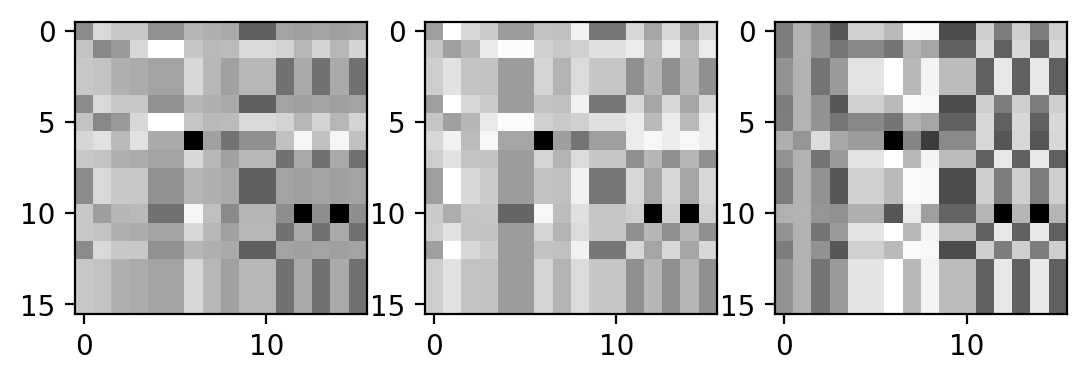

In [97]:
plt.subplot(1,3,1)
plt.imshow(m_adapter, cmap='gray_r')
plt.subplot(1,3,2)
plt.imshow(m_graph, cmap='gray_r')
plt.subplot(1,3,3)
plt.imshow(m_token, cmap='gray_r')